# Pokemon VGC Win Predictor Training

This notebook generates synthetic match data using Monte Carlo simulations and trains a Random Forest model to predict the winner based on team synergy metrics.

In [1]:
import sys
import os
import pandas as pd

# Add src directory to path
sys.path.append('../src')

from win_predictor import WinProbabilityModel

# Initialize the model handler
predictor = WinProbabilityModel()

## 1. Generate Synthetic Match Data

We will simulate matches between random teams of 4 Pokemon to create a labeled dataset.

In [2]:
# Generate 1000 synthetic matches for better model accuracy
match_df = predictor.generate_synthetic_matches(num_matches=1000)

print(f"Generated {len(match_df)} valid match records.")
match_df.head()

Generating 1000 synthetic matchups...
Simulating match 0/1000...
Simulating match 100/1000...
Simulating match 200/1000...
Simulating match 300/1000...
Simulating match 400/1000...
Simulating match 500/1000...
Simulating match 600/1000...
Simulating match 700/1000...
Simulating match 800/1000...
Simulating match 900/1000...
Generated 1000 valid match records.


,a_weakness_overlap,a_resistance_coverage,a_role_balance,a_speed_variance,a_bst_efficiency,b_weakness_overlap,b_resistance_coverage,b_role_balance,b_speed_variance,b_bst_efficiency,team_a_wins
0,1,0.833333,1.00,1.000000,0.870117,0,0.666667,0.75,0.866025,0.867789,1
1,0,0.666667,0.50,1.500000,0.835069,1,0.611111,0.50,1.479020,0.856459,1
2,0,0.666667,0.50,0.433013,0.855200,0,0.833333,0.75,0.829156,0.882327,0
3,0,0.888889,1.00,1.299038,0.850759,0,0.555556,0.75,1.118034,0.863643,1
4,0,0.611111,0.75,1.089725,0.858109,0,0.555556,1.00,0.707107,0.844818,1


## 2. Train Win Prediction Model

We use a Random Forest Classifier to learn the relationship between team features (Weakness Overlap, Role Balance, Speed Variance, BST Efficiency) and the likelihood of winning.

In [3]:
# Train the model and save to ../models/win_predictor_rf.pkl
X_train = predictor.train_model(match_df)

Training Random Forest Win Predictor...

--- Model Performance ---
ROC-AUC Score: 0.709
              precision    recall  f1-score   support

           0       0.70      0.57      0.63       112
           1       0.56      0.68      0.61        88

    accuracy                           0.62       200
   macro avg       0.63      0.63      0.62       200
weighted avg       0.63      0.62      0.62       200

Model saved to ../models/win_predictor_rf.pkl


## 3. Analyze Feature Importance

Let's see which team metrics are most predictive of a win.

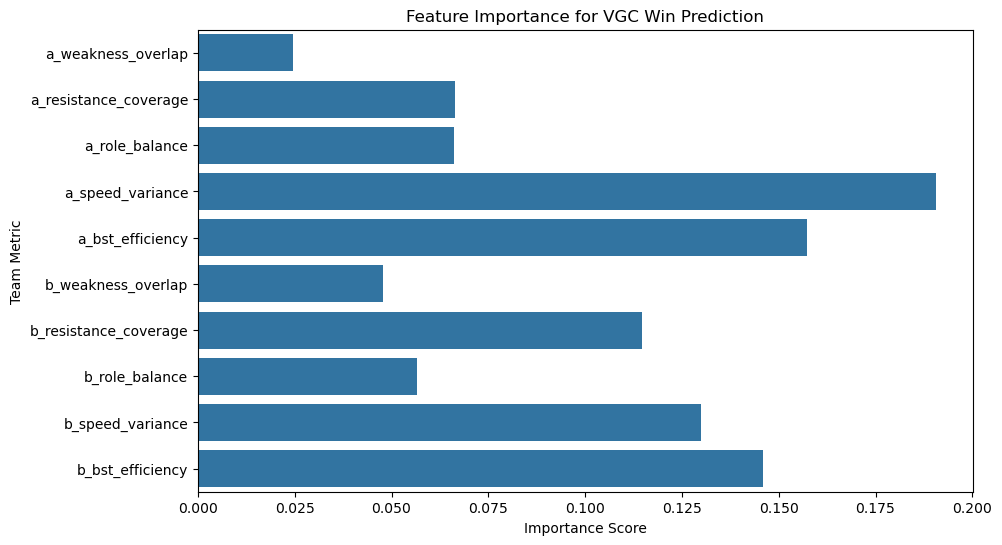

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = predictor.model.feature_importances_
feature_names = X_train.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance for VGC Win Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Team Metric")
plt.show()